In [1]:
from blackjack_game import BlackjackGame

import analytique
from analytique import get_B_croupier
from analytique import get_P_joueur
from analytique import get_all_esperance_hit
from analytique import get_choice_matrix
from analytique import get_pair_matrix
from analytique import transform_to_strategy
from analytique import get_col_df

import optuna

import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.animation import FuncAnimation

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

### Import de quelques règles classiques, deck supposé infini

Ici toutes ces règles ont analytiquement la même stratégie optimale (voir basic_strategy_002).   
Pour certaines valeurs de paramètres comme (max_split = 1 ou double_after_split = False) la politique optimale est différente, il faut donc la recalculer  ! (pas implémenter ici) 

In [2]:
# Règles de certains casinos, 2 splits, pas d'abandon
rules_NoSur_2 = {
    "markov": True,
    "hole_card": False,

    "max_split": 2, 
    "resplit_after_ace_split": False, 
    "hit_after_ace_split": False, 

    "double_any_hands": True,
    "double_after_split": True, 

    "surrender" : False, 
    "surr_to_ace": False
}

# Règles classiques de Casino : 2 splits, abandon possible mais interdit sur As
rules_Sur_NoA_2 = {
    "markov": True,
    "hole_card": False,

    "max_split": 2, 
    "resplit_after_ace_split": False, 
    "hit_after_ace_split": False, 

    "double_any_hands": True,
    "double_after_split": True, 

    "surrender" : True, 
    "surr_to_ace": False
}

# 2 splits, Abandon possible 
rules_Sur_A_2 = {
    "markov": True,
    "hole_card": False,

    "max_split": 2, 
    "resplit_after_ace_split": False, 
    "hit_after_ace_split": False, 

    "double_any_hands": True,
    "double_after_split": True, 

    "surrender" : True, 
    "surr_to_ace": True
}

# Règles le plus avantageuses pour le joueur : splits illimité et abandon possible meme sur As
rules_Sur_A_inf = {
    "markov": True,
    "hole_card": False,

    "max_split": np.inf, 
    "resplit_after_ace_split": False, 
    "hit_after_ace_split": False, 

    "double_any_hands": True,
    "double_after_split": True, 

    "surrender" : True, 
    "surr_to_ace": True
}

### Calcul analytique de la stratégie optimale pour les paramètres suivant : 

- $N = \infty$
- max_split = 2
- double_any_hands = True
- double_after_split = True
- resplit_after_ace = False
- hit_after_ace_split = False
- proportion de sabot classique


In [3]:
def get_strat_from_prop(prop, max_splits): 
    B = get_B_croupier(prop)
    P = get_P_joueur(prop)

    dic_esperance_hit = get_all_esperance_hit(B=B, P=P)
    
    hard = get_choice_matrix(B, P, dic_esperance_hit, choice='hard')
    soft = get_choice_matrix(B, P, dic_esperance_hit, choice='soft')
    pair = get_pair_matrix(B, P, dic_esperance_hit, prop, max_splits)

    return hard, soft, pair

In [4]:
standard_proportions = {
    'A': 4/52,
    '2': 4/52,
    '3': 4/52,
    '4': 4/52,
    '5': 4/52,
    '6': 4/52,
    '7': 4/52,
    '8': 4/52,
    '9': 4/52,
    '10': 16/52
}
hard, soft, pair = get_strat_from_prop(prop = standard_proportions, max_splits=2)

In [5]:
get_col_df(hard, choice='hard')

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,H,H,H,H,H,H,H,H,H,H
5,H,H,H,H,H,H,H,H,H,Ah
6,H,H,H,H,H,H,H,H,H,Ah
7,H,H,H,H,H,H,H,H,H,Ah
8,H,H,H,H,H,H,H,H,H,H
9,H,Dh,Dh,Dh,Dh,H,H,H,H,H
10+,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
11,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,H,H,S,S,S,H,H,H,H,Ah


In [6]:
get_col_df(soft, choice='soft')

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
AA,H,H,H,H,H,H,H,H,H,H
A2,H,H,H,H,Dh,H,H,H,H,H
A3,H,H,H,Dh,Dh,H,H,H,H,H
A4,H,H,H,Dh,Dh,H,H,H,H,H
A5,H,H,Dh,Dh,Dh,H,H,H,H,H
A6,H,Dh,Dh,Dh,Dh,H,H,H,H,H
A7,S,Ds,Ds,Ds,Ds,S,S,H,H,H
A8,S,S,S,S,S,S,S,S,S,S
A9,S,S,S,S,S,S,S,S,S,S


In [7]:
get_col_df(pair, choice='pair')

Carte croupier,2,3,4,5,6,7,8,9,10,A
Main joueur,,,,,,,,,,
4,SP,SP,SP,SP,SP,SP,H,H,H,H
6,SP,SP,SP,SP,SP,SP,H,H,H,Ah
8,H,H,H,SP,SP,H,H,H,H,H
10,Dh,Dh,Dh,Dh,Dh,Dh,Dh,Dh,H,H
12,SP,SP,SP,SP,SP,H,H,H,H,Ah
14,SP,SP,SP,SP,SP,SP,H,H,Ah,Ah
16,SP,SP,SP,SP,SP,SP,SP,SP,Ah,Ah
18,SP,SP,SP,SP,SP,SP,SP,SP,S,S
20,S,S,S,S,S,S,S,S,S,S


### Test politique optimale sur 2 parties (Monte-Carlo)

In [8]:
game = BlackjackGame(num_decks=np.inf, reshuffle_pct=0, rules=rules_NoSur_2)
balance = 1000

for _ in range(2):
    result, true_count, info = game.play_round(game.basic_strategy_dic, bet=10)
    balance += result
    info = f"ROUND {_+1}\n" + info
    info += f"New balance: {balance}\n"
    info += "-" * 20 + '\n'
    print(info)

ROUND 1
Player's hand: Hand([5 of Diamonds, 3 of Diamonds])
Dealer's hand: 7 of Diamonds and [Hidden]
Player hits: Hand([5 of Diamonds, 3 of Diamonds, 10 of Diamonds])

Dealer's final hand: Hand([7 of Diamonds, 10 of Diamonds])

Player wins with 18 against dealer's 17
New balance: 1010
--------------------

ROUND 2
Player's hand: Hand([A of Diamonds, J of Diamonds])
Dealer's hand: 5 of Diamonds and [Hidden]

Dealer's final hand: Hand([5 of Diamonds, 7 of Diamonds, 10 of Diamonds])

BLACKJACK! Player wins with 21 against dealer's 22
New balance: 1025.0
--------------------



In [9]:
def simulate_monte_carlo_v4(strategy="best", initial_balance= 1000, num_games=100,
                         num_rounds_per_game=200, num_decks=np.inf, reshuffle_pct=80, 
                         rules=rules_Sur_A_inf, prop='default', initial_bet=10, return_count = False):
    game_settings = {
        "num_decks": num_decks,
        "reshuffle_pct": reshuffle_pct, 
        "rules": rules, 
        "prop": prop
    }

    gain_histories = np.zeros((num_games, num_rounds_per_game), dtype=np.float32)
    count_dic = defaultdict(list)

    for game_num in range(num_games):
        game = BlackjackGame(**game_settings)
        strat = game.basic_strategy_dic if strategy == "best" else strategy

        for round_idx in range(num_rounds_per_game):
            result, true_count = game.play_round(strat, bet=initial_bet, return_info=False)

            gain_histories[game_num, round_idx] = result 
            if return_count : 
                count_dic[round(true_count, 3)].append(result) 

    balance_histories = np.cumsum(gain_histories, axis=1) + initial_balance

    if return_count : 
        return gain_histories, balance_histories, count_dic
            
    return gain_histories, balance_histories

In [10]:
def get_mean_counting(count_dic):
    return {k:np.mean(v) for k, v in count_dic.items()}  

In [11]:
def filter_count_histories(count_dic, min_ele):
    """ 
    Supprime du dictionnaire les élements de count_histories dont les occurences 
    appairaissent moins de min_ele (car sinon variance trop élevée)
    """
    return {k: v for k, v in count_dic.items() if len(v) >= min_ele}

In [12]:
def apply_bankruptcy(cumulative_array):
    """
    Mets à 0 les balance_histories pour une game à partir d'une valeur négative (banqueroute). 
    Utile seulement pour la visu des trajectoires
    """
    is_negative = cumulative_array < 0
    first_neg_idx = np.argmax(is_negative, axis=1)
    has_negative = is_negative.any(axis=1)
    
    n_rows, n_cols = cumulative_array.shape
    mask = np.arange(n_cols)[None, :] >= first_neg_idx[:, None]
    mask &= has_negative[:, None]
    
    result = cumulative_array.copy()
    result[mask] = 0
    return result

In [9]:
def compare_rules_strats(list_compare, strategy="best", initial_balance= 1000, num_games=100,
                         num_rounds_per_game=200, num_decks=np.inf, reshuffle_pct=80, 
                         prop = 'default', initial_bet=10, return_count = False):

    for i, strat in enumerate(list_compare) : 

        gain_histories, balance_histories = simulate_monte_carlo_v4(
        strategy=strategy, initial_balance=initial_balance, num_games= num_games, num_rounds_per_game=num_rounds_per_game, 
        rules = strat,
        num_decks=num_decks,
        reshuffle_pct=reshuffle_pct,
        initial_bet=initial_bet, 
        prop=prop,
        return_count = return_count
        )

        esperance_rd = np.mean(gain_histories)
        ecart_type = np.std(gain_histories)
        print(f'====== REGLES/STRATEGIE {i+1} : =======')
        print('Abandon : ', strat['surrender'])
        print('Abandon sur As : ', strat['surr_to_ace'])
        print('Nombre splits : ', strat['max_split'])
        print(f"Avantage du joueur : {np.round((esperance_rd/initial_bet)*100, 5)} %")
        print(f"Ecart type : {np.round((ecart_type/initial_bet)*100, 5)} %")
        print()


### Simulation de Monte-Carlo : Stratégies optimales pour différentes règles, N = $ +\infty$

In [23]:
# /!\ cellule prends + de 1h réduire num_rounds_per_game sinon 
compare_rules_strats(list_compare=[rules_NoSur_2, rules_Sur_NoA_2, rules_Sur_A_2, rules_Sur_A_inf],
    strategy="best", initial_balance=1_000_000, num_games= 100, num_rounds_per_game=300_000, 
    num_decks=500,
    reshuffle_pct=80,
    initial_bet=2
)

====== REGLES/STRATEGIE 1 : =======
Abandon :  False
Abandon sur As :  False
Nombre splits :  2
Avantage du joueur : -0.60592 %
Ecart type : 113.35806 %

====== REGLES/STRATEGIE 2 : =======
Abandon :  True
Abandon sur As :  False
Nombre splits :  2
Avantage du joueur : -0.36494 %
Ecart type : 111.21919 %

====== REGLES/STRATEGIE 3 : =======
Abandon :  True
Abandon sur As :  True
Nombre splits :  2
Avantage du joueur : 0.01441 %
Ecart type : 110.04193 %

====== REGLES/STRATEGIE 4 : =======
Abandon :  True
Abandon sur As :  True
Nombre splits :  inf
Avantage du joueur : 0.06051 %
Ecart type : 110.2579 %



### Simulation de Monte-Carlo : Stratégie aléatoire (Tirer ou Stand seulement), N = $ +\infty$

In [21]:
compare_rules_strats(list_compare=[rules_Sur_A_inf],
    strategy="random", initial_balance=1_000_000, num_games= 100, num_rounds_per_game=3000, 
    num_decks=500,
    reshuffle_pct=80,
    initial_bet=2
)

====== REGLES/STRATEGIE 1 : =======
Abandon :  True
Abandon sur As :  True
Nombre splits :  inf
Avantage du joueur : -38.63183 %
Ecart type : 91.61171 %



In [20]:
compare_rules_strats(list_compare=[rules_Sur_A_inf],
    strategy="best", initial_balance=1_000_000, num_games= 100, num_rounds_per_game=3000, 
    num_decks=500,
    reshuffle_pct=80,
    initial_bet=2
)

====== REGLES/STRATEGIE 1 : =======
Abandon :  True
Abandon sur As :  True
Nombre splits :  inf
Avantage du joueur : 0.117 %
Ecart type : 110.27966 %



### Convergence de l'estimateur de l'espérance

In [53]:
opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy="best", initial_balance=2000, num_games= 100_000, num_rounds_per_game=300, 
    rules = rules_Sur_A_2,
    num_decks=500,
    initial_bet=10, 
)

In [65]:
random_gain_histories, random_balance_histories = simulate_monte_carlo_v4(
    strategy="random", initial_balance=2000, num_games= 1000, num_rounds_per_game=300, 
    rules = rules_Sur_A_2,
    num_decks=500,
    initial_bet=10, 
)

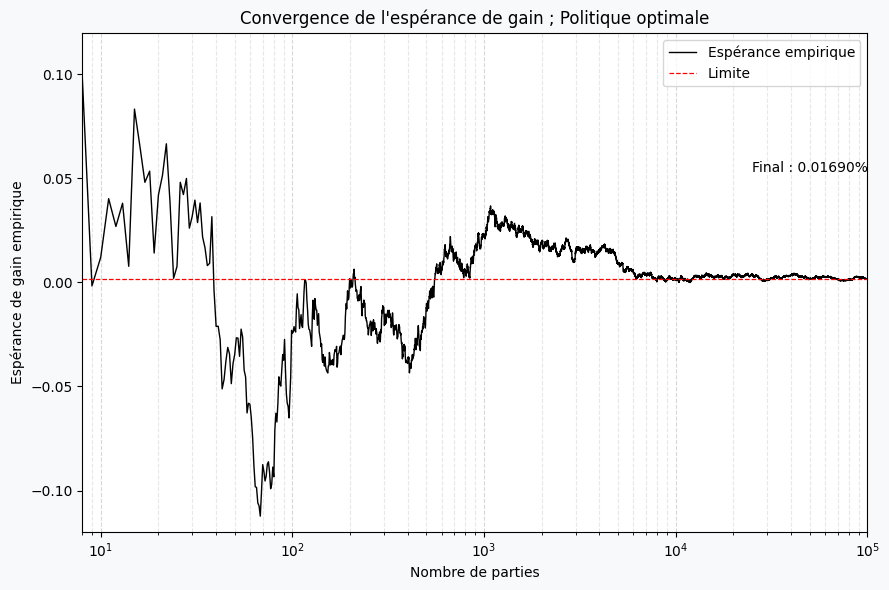

In [64]:
gain_histories = np.array(opt_gain_histories)

cumulative_sum = np.cumsum(gain_histories, axis=0)
mean_gains = (cumulative_sum.sum(axis=1) / ((np.arange(1, gain_histories.shape[0] + 1)) * gain_histories.shape[1])).astype(np.float32)

final_expectation = mean_gains[-1]
pos_y = (max(mean_gains) - min(mean_gains)) / 20

#mean_gains[2] = -0.14
#mean_gains[3] = -0.04

final_expectation = mean_gains[-1]
plt.figure(figsize=(9, 6), facecolor="#f8f9fa")
plt.plot(mean_gains, color='black', linewidth=1, label='Espérance empirique')

plt.text(
    x=len(mean_gains) - 1,
    y=final_expectation + pos_y,
    s=f"Final : {final_expectation * 10:.5f}%",
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
    color='black'
)

plt.axhline(final_expectation, color='red', linestyle='--', linewidth=0.9, label='Limite')

plt.ylim(-0.12, 0.12)
plt.xlim(8, len(opt_gain_histories))

plt.xlabel('Nombre de parties')
plt.ylabel('Espérance de gain empirique')
plt.title("Convergence de l'espérance de gain ; Politique optimale")

plt.xscale('log')

ax = plt.gca()
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(1.0, 10.0)*0.1, numticks=10))
ax.grid(which='minor', axis='x', linestyle='--', alpha=0.3)  # grille pour ticks mineurs
ax.grid(which='major', axis='x', linestyle='--', alpha=0.5)  # grille pour ticks majeurs

plt.legend()
plt.tight_layout()
plt.show()


### Simuation de trajectoires : optimale vs aléatoire

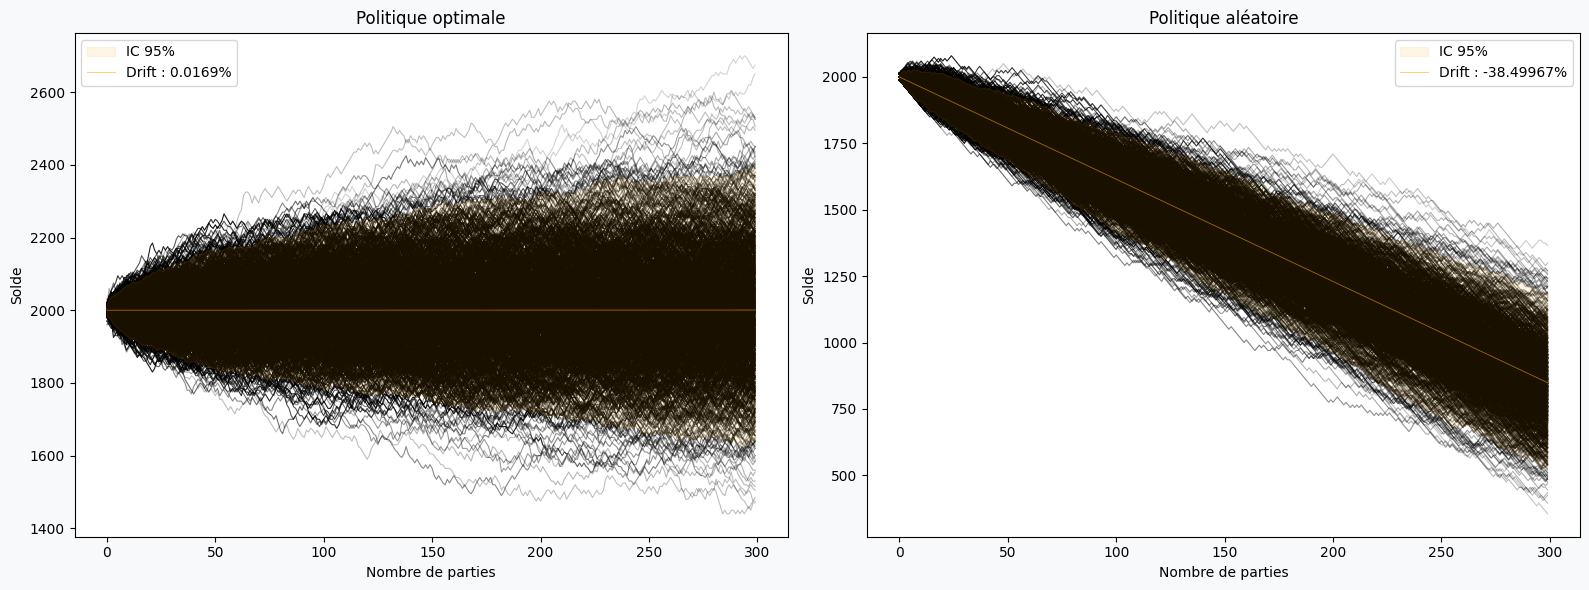

In [67]:
n_traj = 800
alpha_coef = 0.5

esperance_rd = np.mean(opt_gain_histories)
esperance_random = np.mean(random_gain_histories)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="#f8f9fa")

trajectoires = np.array(opt_balance_histories[:n_traj])
x = np.arange(trajectoires.shape[1])

final_values = trajectoires[:, -1]
mean_final = np.mean(final_values)
std_final = np.std(final_values)
z = np.abs((final_values - mean_final) / std_final)
alpha_vals = np.exp(-alpha_coef * z)

for traj, a in zip(trajectoires, alpha_vals):
    axes[0].plot(x, traj, color='black', alpha=a, linewidth=0.8, zorder=1)

low = np.percentile(trajectoires, 2.5, axis=0)
high = np.percentile(trajectoires, 97.5, axis=0)
axes[0].fill_between(x, low, high, color='orange', alpha=0.1, label='IC 95%', zorder=2)

trend = 2000 + esperance_rd * x
axes[0].plot(x, trend, color='orange', linewidth=0.6, label=f'Drift : {np.round(esperance_rd*10,5)}%', zorder=3, alpha = 0.6)

axes[0].set_xlabel('Nombre de parties')
axes[0].set_ylabel('Solde')
axes[0].set_title("Politique optimale")
axes[0].legend()

trajectoires = np.array(random_balance_histories[:n_traj])

final_values = trajectoires[:, -1]
mean_final = np.mean(final_values)
std_final = np.std(final_values)
z = np.abs((final_values - mean_final) / std_final)
alpha_vals = np.exp(-alpha_coef * z)

for traj, a in zip(trajectoires, alpha_vals):
    axes[1].plot(x, traj, color='black', alpha=a, linewidth=0.8, zorder=1)

low = np.percentile(trajectoires, 2.5, axis=0)
high = np.percentile(trajectoires, 97.5, axis=0)
axes[1].fill_between(x, low, high, color='orange', alpha=0.1, label='IC 95%', zorder=2)

trend = 2000 + esperance_random * x
axes[1].plot(x, trend, color='orange', linewidth=0.6, label=f'Drift : {np.round(esperance_random*10,5)}%', zorder=3, alpha = 0.6)

axes[1].set_xlabel('Nombre de parties')
axes[1].set_ylabel('Solde')
axes[1].set_title("Politique aléatoire")
axes[1].legend()

plt.tight_layout()
plt.show()

### Distribution de gains : optimale vs aléatoire

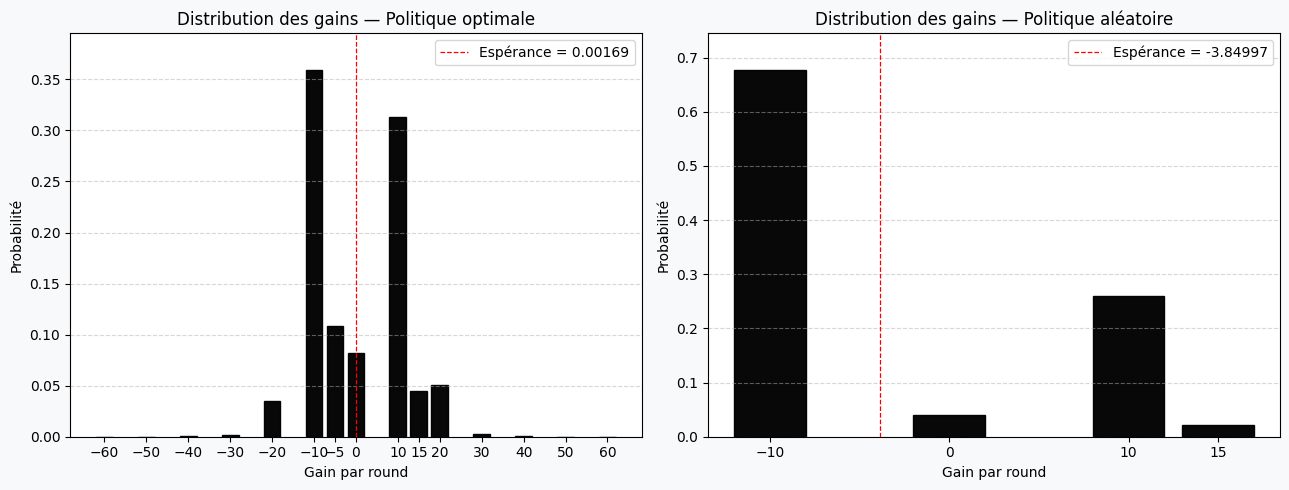

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#f8f9fa")

# ------------------- Politique optimale -------------------
gain_histories = np.array(opt_gain_histories)
all_gains = gain_histories.flatten()
unique, counts = np.unique(all_gains, return_counts=True)
probabilities = counts / counts.sum()
mean_gain = np.mean(all_gains)

axes[0].bar(unique, probabilities, width=4, edgecolor='black', color='black', alpha = 0.97)
axes[0].axvline(mean_gain, color='red', linestyle='--', linewidth=0.9, label=f'Espérance = {mean_gain:.5f}')
axes[0].set_xlabel('Gain par round')
axes[0].set_ylabel('Probabilité')
axes[0].set_title('Distribution des gains — Politique optimale')
axes[0].set_xticks(unique)
axes[0].set_ylim(0, max(probabilities) * 1.1)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].legend()

# ------------------- Politique aléatoire -------------------
gain_histories = np.array(random_gain_histories)
all_gains = gain_histories.flatten()
unique, counts = np.unique(all_gains, return_counts=True)
probabilities = counts / counts.sum()
mean_gain = np.mean(all_gains)

axes[1].bar(unique, probabilities, width=4, edgecolor='black', color='black', alpha = 0.97)
axes[1].axvline(mean_gain, color='red', linestyle='--', linewidth=0.9, label=f'Espérance = {mean_gain:.5f}')
axes[1].set_xlabel('Gain par round')
axes[1].set_ylabel('Probabilité')
axes[1].set_title('Distribution des gains — Politique aléatoire')
axes[1].set_xticks(unique)
axes[1].set_ylim(0, max(probabilities) * 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

### Probabilité et espérance de temps de ruine du joueur

In [10]:
def monte_carlo_ruine(b, strategy="best", initial_balance= 1000, num_games=100,
                          num_decks=6, reshuffle_pct=80, 
                         rules=rules_Sur_A_2, initial_bet=10):
    game_settings = {
        "num_decks": num_decks,
        "reshuffle_pct": reshuffle_pct, 
        "rules": rules
    }
    
    proba_a = 0

    list_e_T = []

    for i in range(num_games) :
        game = BlackjackGame(**game_settings)
        sum_balances = 0
        T = 0
        while sum_balances > - initial_balance and sum_balances < b :
            strat = game.basic_strategy_dic if strategy == "best" else "random"
            result, true_count = game.play_round(strat, bet=initial_bet, return_info=False)
            sum_balances += result
            T += 1
        if sum_balances <= - initial_balance :
            proba_a +=1

        list_e_T.append(T) 

            
    return proba_a/num_games,  np.mean(list_e_T)

In [11]:
def get_dic_ruine(rules, num_games, strategy, list_a, list_b, list_alpha) : 
    results = {}

    for alpha in list_alpha:
        proba_list = []
        e_t_list = []
        coords = []

        for a in list_a:
            for b in list_b:
                proba_a, e_t = monte_carlo_ruine(
                    b=b,
                    initial_balance=a,
                    initial_bet=alpha,
                    rules=rules,
                    num_games=num_games, 
                    strategy=strategy
                    
                )
                proba_list.append(proba_a)
                e_t_list.append(e_t)
                coords.append((a, b))
        
        results[alpha] = {
            "proba": proba_list,
            "e_t": e_t_list,
            "coords": coords
        }
    return results

In [89]:
## Cellule longue ~ 30 mins

list_a = list(range(5, 20, 1))     # valeurs de a (balance initiale)
list_b = list_a.copy()              # valeurs de b (seuils)
list_alpha = [1, 2, 5, 10, 20]    # alpha de 1 à 10
num_games = 1000                    # nombre de parties Monte Carlo

results_random = get_dic_ruine(rules = rules_Sur_A_2, num_games=num_games, strategy='random', list_a=list_a, list_b=list_b, list_alpha=list_alpha)
results_opt = get_dic_ruine(rules = rules_Sur_A_2, num_games=num_games, strategy='best', list_a=list_a, list_b=list_b, list_alpha=list_alpha)
alphas = sorted(results_opt.keys())

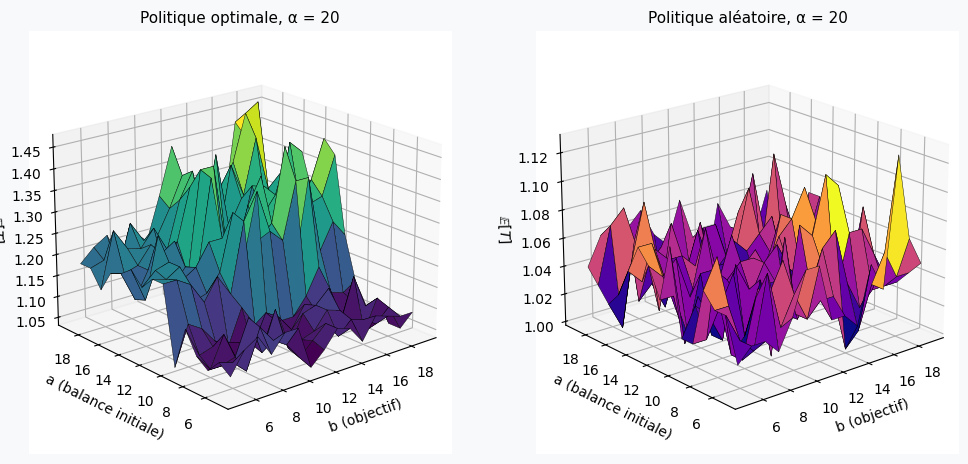

In [ ]:
def make_grid(data):
    a_vals = [x[0] for x in data["coords"]]
    b_vals = [x[1] for x in data["coords"]]
    e_vals = data["e_t"]

    a_unique = sorted(set(a_vals))
    b_unique = sorted(set(b_vals))
    Z = np.zeros((len(a_unique), len(b_unique)))

    for (a, b, e) in zip(a_vals, b_vals, e_vals):
        i = a_unique.index(a)
        j = b_unique.index(b)
        Z[i, j] = e

    A, B = np.meshgrid(b_unique, a_unique)
    return A, B, Z

fig = plt.figure(figsize=(12, 6), facecolor="#f8f9fa")
ax_opt = fig.add_subplot(1, 2, 1, projection='3d')
ax_rand = fig.add_subplot(1, 2, 2, projection='3d')

def update(frame):
    ax_opt.cla()
    ax_rand.cla()

    alpha = alphas[frame]
    data_opt = results_opt[alpha]                                           
    data_rand = results_random[alpha]

    A_opt, B_opt, Z_opt = make_grid(data_opt)
    A_rand, B_rand, Z_rand = make_grid(data_rand)

    ax_opt.plot_surface(A_opt, B_opt, Z_opt, cmap='viridis', edgecolor='k', linewidth=0.3)
    ax_opt.set_title(f"Politique optimale, α = {alpha}", fontsize=11)
    ax_opt.set_xlabel("b (objectif)")
    ax_opt.set_ylabel("a (balance initiale)")
    ax_opt.set_zlabel(r"$\mathbb{E}[T]$")
    ax_opt.view_init(elev=20, azim=230)  
    

    ax_rand.plot_surface(A_rand, B_rand, Z_rand, cmap='plasma', edgecolor='k', linewidth=0.3)
    ax_rand.set_title(f"Politique aléatoire, α = {alpha}", fontsize=11)
    ax_rand.set_xlabel("b (objectif)")
    ax_rand.set_ylabel("a (balance initiale)")
    ax_rand.set_zlabel(r"$\mathbb{E}[T]$")
    ax_rand.view_init(elev=20, azim=230)                                                                                                                                                        


ani = FuncAnimation(fig, update, frames=len(alphas), interval=1200, repeat=True)

ani.save("comparaison_3d_et.gif", writer="pillow")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

vmin, vmax = 0.24, 0.95  # bornes fixes pour toutes les cartes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), facecolor="#f8f9fa")

alpha_cible = alphas[0]

def get_Z(data):
    a_vals = [x[0] for x in data["coords"]]
    b_vals = [x[1] for x in data["coords"]]
    probas = data["proba"]
    a_unique = sorted(set(a_vals))
    b_unique = sorted(set(b_vals))
    Z = np.zeros((len(a_unique), len(b_unique)))
    for (a, b, p) in zip(a_vals, b_vals, probas):
        i = a_unique.index(a)
        j = b_unique.index(b)
        Z[i, j] = p
    return Z, a_unique, b_unique

Z_opt, a_u, b_u = get_Z(results_opt[alpha_cible])
Z_rand, _, _ = get_Z(results_random[alpha_cible])

img1 = ax1.imshow(Z_opt, origin='lower', cmap='viridis_r',
                  extent=[min(b_u), max(b_u), min(a_u), max(a_u)],
                  aspect='equal', vmin=vmin, vmax=vmax)
ax1.set_title(f'Politique optimale, α={alpha_cible}')
ax1.set_xlabel('b (objectif)')
ax1.set_ylabel('a (balance initiale)')
ax1.grid(False)

img2 = ax2.imshow(Z_rand, origin='lower', cmap='viridis_r',
                  extent=[min(b_u), max(b_u), min(a_u), max(a_u)],
                  aspect='equal', vmin=vmin, vmax=vmax)
ax2.set_title(f'Politique aléatoire, α={alpha_cible}')
ax2.set_xlabel('b (objectif)')
ax2.set_ylabel('a (balance initiale)')
ax2.grid(False)

cbar = fig.colorbar(img1, ax=[ax1, ax2], label='Probabilité de ruine')

def update(alpha_cible):
    Z_opt, _, _ = get_Z(results_opt[alpha_cible])
    Z_rand, _, _ = get_Z(results_random[alpha_cible])
    img1.set_data(Z_opt)
    img2.set_data(Z_rand)
    ax1.set_title(f'Politique optimale, α={alpha_cible}')
    ax2.set_title(f'Politique aléatoire, α={alpha_cible}')
    return [img1, img2]

ani = animation.FuncAnimation(fig, update, frames=alphas, blit=False, repeat=True)

ani.save("probabilite_ruine_double.gif", writer='pillow', fps=1)
plt.close()


✅ GIF double graphique enregistré sous 'probabilite_ruine_double.gif'


### Proportions maximisant l'espérance

In [18]:
def get_strat_from_prop(prop, max_splits): 
    B = get_B_croupier(prop)
    P = get_P_joueur(prop)

    dic_esperance_hit = get_all_esperance_hit(B=B, P=P)
    
    hard = get_choice_matrix(B, P, dic_esperance_hit, choice='hard')
    soft = get_choice_matrix(B, P, dic_esperance_hit, choice='soft')
    pair = get_pair_matrix(B, P, dic_esperance_hit, prop, max_splits)

    return hard, soft, pair

In [19]:
proportions = {
    'A': 9/52,
    '2': 1/52,
    '3': 1/52,
    '4': 1/52,
    '5': 4/52,
    '6': 4/52,
    '7': 4/52,
    '8': 4/52,
    '9': 4/52,
    '10': 20/52
}

proportions_2 = {
    'A': 15/52,
    '2': 0,
    '3': 0,
    '4': 0,
    '5': 0,
    '6': 3/52,
    '7': 3/52,
    '8': 3/52,
    '9': 3/52,
    '10': 25/52
}



list_cards = list(proportions.keys())
max_splits = 2

In [25]:
## Test 
hard, soft, pair = get_strat_from_prop(new_pp, max_splits)
strat = transform_to_strategy(hard, soft, pair)

In [11]:
bet = 2
# OK MAIS TRES LONG
opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy=strat, initial_balance=100_000, num_games= 100, num_rounds_per_game=3000, 
    rules = rules_Sur_A_2,
    num_decks=500,
    initial_bet=bet, 
    prop=proportions
    )

(np.mean(opt_gain_histories) / bet)*100

11.921166628599167

In [ ]:
bet = 2
#Pour comparer...
opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy=strat, initial_balance=100_000, num_games= 100, num_rounds_per_game=3000, 
    rules = rules_Sur_A_2,
    num_decks=500,
    initial_bet=bet
    )

(np.mean(opt_gain_histories) / bet)*100

-1.7614999786019325

In [26]:
bet = 2
## bizarrement meilleur ? 
opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy=strat, initial_balance=100_000, num_games= 100, num_rounds_per_game=2000, 
    rules = rules_Sur_A_2,
    num_decks=np.inf,
    prop=new_pp,
    initial_bet=bet
    )

(np.mean(opt_gain_histories) / bet)*100

253.11150550842285

In [27]:
game = BlackjackGame(num_decks=np.inf, reshuffle_pct=0, rules=rules_NoSur_2, prop= new_pp)
balance = 1000

for _ in range(2):
    result, true_count, info = game.play_round(strat, bet=10)
    balance += result
    info = f"ROUND {_+1}\n" + info
    info += f"New balance: {balance}\n"
    info += "-" * 20 + '\n'
    print(info)

ROUND 1
Player's hand: Hand([2 of Diamonds, 2 of Diamonds])
Dealer's hand: 2 of Diamonds and [Hidden]
Player splits: Hand([2 of Diamonds, 2 of Diamonds]) and Hand([2 of Diamonds, 2 of Diamonds])

Player's hand: Hand([2 of Diamonds, 2 of Diamonds])
Dealer's hand: 2 of Diamonds and [Hidden]
Player splits: Hand([2 of Diamonds, 2 of Diamonds]) and Hand([2 of Diamonds, 2 of Diamonds])

Player's hand: Hand([2 of Diamonds, 2 of Diamonds])
Dealer's hand: 2 of Diamonds and [Hidden]
Player hits: Hand([2 of Diamonds, 2 of Diamonds, 4 of Diamonds])
Player hits: Hand([2 of Diamonds, 2 of Diamonds, 4 of Diamonds, 2 of Diamonds])
Player hits: Hand([2 of Diamonds, 2 of Diamonds, 4 of Diamonds, 2 of Diamonds, 2 of Diamonds])
Player hits: Hand([2 of Diamonds, 2 of Diamonds, 4 of Diamonds, 2 of Diamonds, 2 of Diamonds, 2 of Diamonds])
Player hits: Hand([2 of Diamonds, 2 of Diamonds, 4 of Diamonds, 2 of Diamonds, 2 of Diamonds, 2 of Diamonds, 2 of Diamonds])
Player hits: Hand([2 of Diamonds, 2 of Diamonds

In [11]:
def objective(trial):
    n = len(list_cards)
    x = []
    for i in range(n):
        x.append(- np.log(trial.suggest_float(f"{list_cards[i]}", 0, 1)))

    p = []
    new_prop = {}

    for i in range(n):
        res = x[i] / sum(x)
        p.append(res)
        new_prop[list_cards[i]] = res
        
    for i in range(n):
        trial.set_user_attr(f"{list_cards[i]}", p[i])

    hard, soft, pair = get_strat_from_prop(new_prop, max_splits)
    strat = transform_to_strategy(hard, soft, pair)

    opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy=strat, initial_balance=100_000, num_games= 100, num_rounds_per_game=2000, 
    rules = rules_Sur_A_2,
    num_decks=np.inf,
    prop=proportions,
    initial_bet=2
    )

    return (np.mean(opt_gain_histories) / 2)*100

study = optuna.create_study(sampler=optuna.samplers.RandomSampler(), direction='maximize')
study.optimize(objective, n_trials=250)

[I 2025-11-27 05:22:15,222] A new study created in memory with name: no-name-10c66618-6648-44d2-8616-96d2edc9c893
[I 2025-11-27 05:22:57,289] Trial 0 finished with value: 6.24300017952919 and parameters: {'A': 0.6924670059282003, '2': 0.3548705560389339, '3': 0.5355325746235744, '4': 0.3335077889731498, '5': 0.582248422029005, '6': 0.6520095721659945, '7': 0.9054472997473338, '8': 0.8948384923337774, '9': 0.2669023862706207, '10': 0.08353034616433908}. Best is trial 0 with value: 6.24300017952919.
[I 2025-11-27 05:23:38,615] Trial 1 finished with value: 5.065000057220459 and parameters: {'A': 0.6655662580079372, '2': 0.5050694944489, '3': 0.7859826663528314, '4': 0.8714887790290319, '5': 0.444135031514063, '6': 0.27901654108786944, '7': 0.15117327259045266, '8': 0.17825774572010022, '9': 0.047681877852132404, '10': 0.5207108021110052}. Best is trial 0 with value: 6.24300017952919.
[I 2025-11-27 05:24:24,578] Trial 2 finished with value: -5.885500088334084 and parameters: {'A': 0.249984

In [ ]:
def objective(trial):
    n = len(list_cards)
    x = []
    for i in range(n):
        x.append(- np.log(trial.suggest_float(f"{list_cards[i]}", 0, 1)))

    p = []
    new_prop = {}

    for i in range(n):
        res = x[i] / sum(x)
        p.append(res)
        new_prop[list_cards[i]] = res
        
    for i in range(n):
        trial.set_user_attr(f"{list_cards[i]}", p[i])

    hard, soft, pair = get_strat_from_prop(new_prop, max_splits)
    strat = transform_to_strategy(hard, soft, pair)

    opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy=strat, initial_balance=100_000, num_games= 100, num_rounds_per_game=2000, 
    rules = rules_Sur_A_2,
    num_decks=np.inf,
    prop=new_prop,
    initial_bet=2
    )

    return (np.mean(opt_gain_histories) / 2)*100

study = optuna.create_study(sampler=optuna.samplers.TPESampler(), direction='maximize')
study.optimize(objective, n_trials=250)

In [ ]:
import optuna
import numpy as np

def objective(trial):
    logits = [trial.suggest_float(f"logit_{c}", -5, 5) for c in list_cards]
    exp_logits = np.exp(logits)
    p = exp_logits / exp_logits.sum()

    new_prop = dict(zip(list_cards, p))

    hard, soft, pair = get_strat_from_prop(new_prop, max_splits)
    strat = transform_to_strategy(hard, soft, pair)

    opt_gain_histories, opt_balance_histories = simulate_monte_carlo_v4(
    strategy=strat, initial_balance=100_000, num_games= 100, num_rounds_per_game=2000, 
    rules = rules_Sur_A_2,
    num_decks=np.inf,
    prop=new_prop,
    initial_bet=2
    )

    return (np.mean(opt_gain_histories) / 2)*100



study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=100)
)

study.optimize(objective, n_trials=300)

[I 2025-11-27 13:02:40,412] A new study created in memory with name: no-name-46b49c6b-369f-46c8-a1e4-d9618c2bf580
[I 2025-11-27 13:03:44,983] Trial 0 finished with value: 18.215249478816986 and parameters: {'logit_A': 4.830349686722821, 'logit_2': 0.47972354346171464, 'logit_3': 2.6452104084579107, 'logit_4': 3.3391671255249893, 'logit_5': 2.4751400829481964, 'logit_6': 3.892025656161703, 'logit_7': 4.782480957188467, 'logit_8': -0.889056043482074, 'logit_9': -1.5664584540835422, 'logit_10': 2.073227111429902}. Best is trial 0 with value: 18.215249478816986.
[I 2025-11-27 13:04:53,253] Trial 1 finished with value: 1.104000024497509 and parameters: {'logit_A': -0.39527632177901495, 'logit_2': 3.721269839287812, 'logit_3': 1.4437357217343294, 'logit_4': 4.359355609244474, 'logit_5': -0.32620144861977174, 'logit_6': -2.8494821233726144, 'logit_7': -2.849640473439161, 'logit_8': 3.8159771635450284, 'logit_9': -0.09768187236296466, 'logit_10': -0.9341213553521346}. Best is trial 0 with valu

In [21]:
a = {'logit_A': -2.678015256391469, 'logit_2': 4.752992200121118, 'logit_3': -1.8154937823612043, 'logit_4': 1.3335515186278617, 'logit_5': -2.1280793272703358, 'logit_6': -3.296640352803033, 'logit_7': -4.9984660217072925, 'logit_8': -1.4650048252485415, 'logit_9': -4.739995312561837, 'logit_10': -2.563643395161975}
logits = list(a.values())
exp_logits = np.exp(logits)
p = exp_logits / exp_logits.sum()

new_pp = {k: v for k, v in zip(list_cards, p)}
